## Uczenie maszynowe – zastosowania
### Zajęcia laboratoryjne
# 3. Regresja liniowa – zadanie

## Zadanie 3

### Część podstawowa (4 punkty)

Plik `fires_thefts.csv` zawiera rzeczywiste dane zebrane przez *U.S. Commission on Civil Rights*, przedstawiające liczbę pożarów w danej dzielnicy na tysiąc gospodarstw domowych (pierwsza kolumna) oraz liczbę włamań w tej samej dzielnicy na tysiąc mieszkańców (druga kolumna). 

Stwórz model (regresja liniowa) przewidujący liczbę włamań na podstawie liczby pożarów:
 * Oblicz parametry $\theta$ krzywej regresyjnej za pomocą metody gradientu prostego (*gradient descent*). Możesz wybrać wersję iteracyjną lub macierzową algorytmu.
 * Wykorzystując uzyskaną krzywą regresyjną przepowiedz liczbę włamań na tysiąc mieszkańców dla dzielnicy, w której występuje średnio 50, 100, 200 pożarów na tysiąc gospodarstw domowych.

### Część zaawansowana (2 punkty)

Dla różnych wartości długości kroku $\alpha \in \{ 0.001, 0.01 , 0.1 \}$ stwórz wykres, który zilustruje progresję wartości $J(\theta)$ dla pierwszych 200 króków algorytmu gradientu prostego:
 * Oś $x$ wykresu to kolejne kroki algorytmu – od 0 do 200.
 * Oś $y$ wykresu to wartosci $J(\theta)$.
 * Wykres powinien skłądać się z trzech krzywych:
   1. dla $\alpha = 0.001$
   2. dla $\alpha = 0.01$
   3. dla $\alpha = 0.1$

Część podstawowa

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

In [33]:
# Wczytanie danych z pliku
data = pd.read_csv("fires_thefts.csv", names=["fires", "thefts"])

# Podgląd danych
print(data.head())

   fires  thefts
0    6.2      29
1    9.5      44
2   10.5      36
3    7.7      37
4    8.6      53


In [34]:
# Zmienna niezależna – liczba pożarów
x = data["fires"].to_numpy()

# Zmienna zależna – liczba włamań
y = data["thefts"].to_numpy()

# Liczba obserwacji
m = len(y)

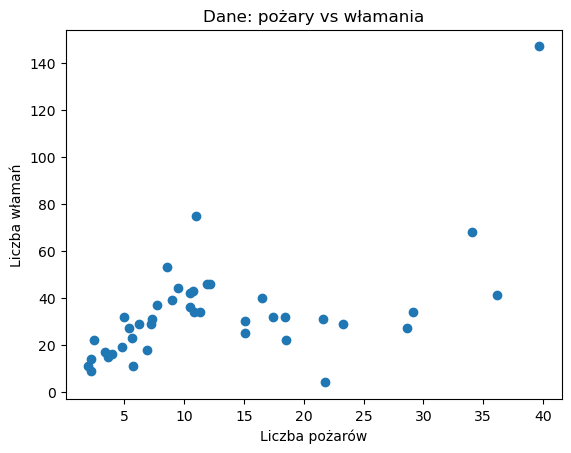

In [35]:
plt.scatter(x, y)
plt.xlabel("Liczba pożarów")
plt.ylabel("Liczba włamań")
plt.title("Dane: pożary vs włamania")
plt.show()

In [36]:
# Hipoteza: funkcja liniowa jednej zmiennej

def h(theta, x):
    return theta[0] + theta[1] * x

In [37]:
# Funkcja kosztu

def J(h, theta, x, y):
    m = len(y)
    return 1/(2*m) * sum((h(theta, x[i]) - y[i])**2 for i in range(m))

In [38]:
def gradient_descent(h, J, theta, x, y, alpha, iterations):

    m = len(y)

    cost_history = []

    for i in range(iterations):

        theta0_grad = sum(h(theta, x[j]) - y[j] for j in range(m)) / m

        theta1_grad = sum((h(theta, x[j]) - y[j]) * x[j] for j in range(m)) / m

        theta[0] = theta[0] - alpha * theta0_grad
        theta[1] = theta[1] - alpha * theta1_grad

        cost = J(h, theta, x, y)
        cost_history.append(cost)

    return theta, cost_history

In [39]:
theta_init = [0.0, 0.0]

alpha = 0.001
iterations = 1000

theta, cost_history = gradient_descent(h, J, theta_init, x, y, alpha, iterations)

print("Wyznaczone parametry theta:")
print(theta)

Wyznaczone parametry theta:
[np.float64(5.222467157383164), np.float64(1.9064597342160285)]


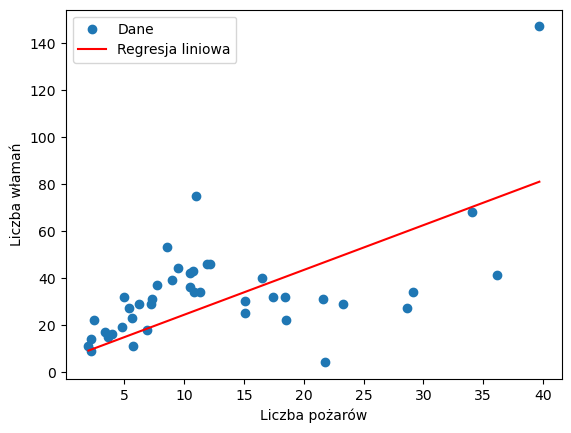

In [40]:
plt.scatter(x, y, label="Dane")

x_line = np.linspace(min(x), max(x), 100)
y_line = h(theta, x_line)

plt.plot(x_line, y_line, color="red", label="Regresja liniowa")

plt.xlabel("Liczba pożarów")
plt.ylabel("Liczba włamań")

plt.legend()
plt.show()

In [41]:
values = [50, 100, 200]

for v in values:
    prediction = h(theta, v)
    print(f"Przewidywana liczba włamań dla {v} pożarów: {prediction:.2f}")

Przewidywana liczba włamań dla 50 pożarów: 100.55
Przewidywana liczba włamań dla 100 pożarów: 195.87
Przewidywana liczba włamań dla 200 pożarów: 386.51


Część zaawansowana

In [42]:
x = (x - np.mean(x)) / np.std(x)
y = (y - np.mean(y)) / np.std(y)

In [43]:
theta_init = [0.0, 0.0]

theta1, cost1 = gradient_descent(h, J, theta_init.copy(), x, y, 0.001, 200)
theta2, cost2 = gradient_descent(h, J, theta_init.copy(), x, y, 0.01, 200)
theta3, cost3 = gradient_descent(h, J, theta_init.copy(), x, y, 0.1, 200)

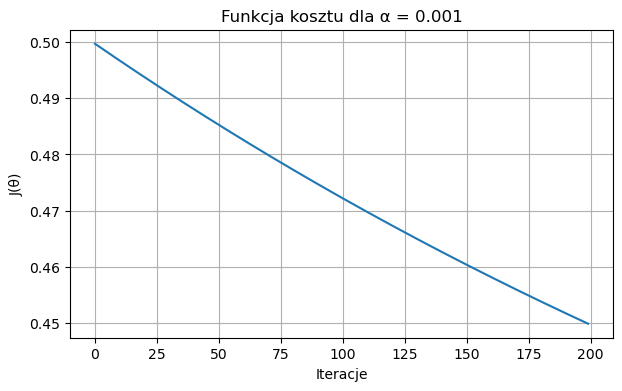

In [44]:
plt.figure(figsize=(7,4))

plt.plot(cost1)

plt.xlabel("Iteracje")
plt.ylabel("J(θ)")
plt.title("Funkcja kosztu dla α = 0.001")

plt.grid(True)
plt.show()

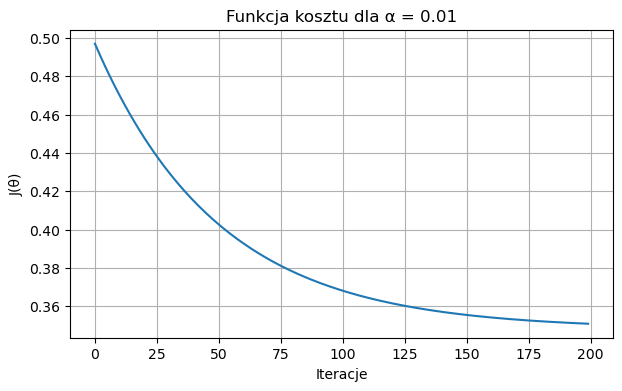

In [45]:
plt.figure(figsize=(7,4))

plt.plot(cost2)

plt.xlabel("Iteracje")
plt.ylabel("J(θ)")
plt.title("Funkcja kosztu dla α = 0.01")

plt.grid(True)
plt.show()

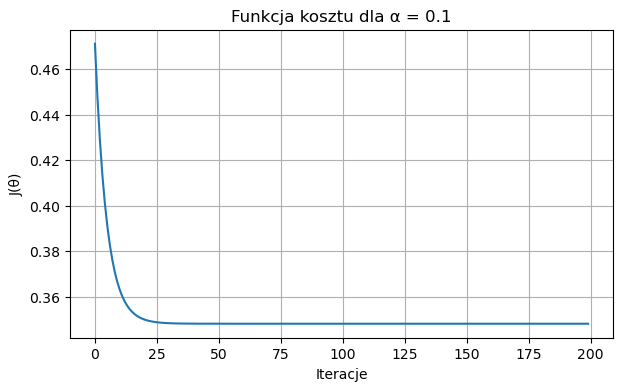

In [46]:
plt.figure(figsize=(7,4))

plt.plot(cost3)

plt.xlabel("Iteracje")
plt.ylabel("J(θ)")
plt.title("Funkcja kosztu dla α = 0.1")

plt.grid(True)
plt.show()

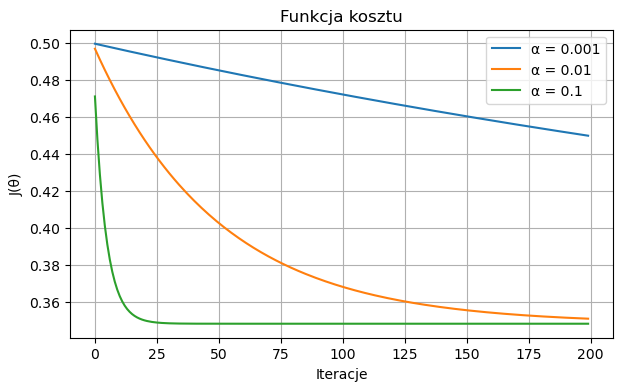

In [47]:
plt.figure(figsize=(7,4))

plt.plot(cost1, label="α = 0.001")
plt.plot(cost2, label="α = 0.01")
plt.plot(cost3, label="α = 0.1")

plt.xlabel("Iteracje")
plt.ylabel("J(θ)")

plt.title("Funkcja kosztu")

plt.legend()

plt.grid(True)

plt.show()